# Group Name: APT

**Group Members:**  
1201102586 Cheng Wei Ning  
1201102471 Liew Wei Ming  
1201102676 Phang Ao Zan  
1191202283 Uithiswary A/P Velan

## Data Wrangling

In [1]:
# Import libraries

import pandas as pd
import numpy as np
from numpy import mean,median
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Read data
data = pd.read_csv(r"Medicaldataset.csv")

In [3]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
1883,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
1884,46,1,0,140,311,0,1,120,1,1.8,1,2,3,0
1885,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
1886,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0
1887,53,1,0,110,335,0,1,143,1,3.0,1,1,3,0


In [5]:
# Display information of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


In [6]:
# Display statistical value of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1888.0,54.354343,9.081505,29.0,47.75,55.0,61.0,77.0
sex,1888.0,0.688559,0.463205,0.0,0.00,1.0,1.0,1.0
cp,1888.0,1.279131,1.280877,0.0,0.00,1.0,2.0,4.0
trestbps,1888.0,131.549258,17.556985,94.0,120.00,130.0,140.0,200.0
chol,1888.0,246.855403,51.609329,126.0,211.00,241.0,276.0,564.0
fbs,1888.0,0.148305,0.355496,0.0,0.00,0.0,0.0,1.0
restecg,1888.0,0.597458,0.638820,0.0,0.00,1.0,1.0,2.0
thalachh,1888.0,149.424258,23.006153,71.0,133.00,152.0,166.0,202.0
exang,1888.0,0.331568,0.470901,0.0,0.00,0.0,1.0,1.0
oldpeak,1888.0,1.053761,1.161344,0.0,0.00,0.8,1.6,6.2


In [7]:
# Convert non-numeric columns to numeric

for col in data.columns:
    if not pd.api.types.is_numeric_dtype(data[col]):
        try:
            data[col] = pd.to_numeric(data[col],errors='coerce')
        except ValueError: # Handle cases where conversion is not possible
            print(f"Could not convert column '{col}' to numeric.")

In [8]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1883,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
1884,46,1,0,140,311,0,1,120,1,1.8,1,2,3,0
1885,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
1886,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0


In [9]:
# Display fonal converted data type
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [10]:
# Check for missing value
data.isnull()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1883,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1884,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1885,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1886,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
# Extract rows and columns where data is missing
missing_values = data[data.isnull().any(axis=1)][data.columns[data.isnull().any(axis=0)]]
print("\nRows and columns with missing values:")
print(missing_values)


Rows and columns with missing values:
Empty DataFrame
Columns: []
Index: []


In [12]:
# Check if there is any missing values with '?', replace it with NaN
data = data.replace('?', np.nan)

print('\nNumber of instances = %d' % (data.shape[0]))
print('Number of attributes = %d' % (data.shape[1]))

print('Number of misisng values:')
for col in data.columns:
    print('\t%s: %d' % (col,data[col].isna().sum()))


Number of instances = 1888
Number of attributes = 14
Number of misisng values:
	age: 0
	sex: 0
	cp: 0
	trestbps: 0
	chol: 0
	fbs: 0
	restecg: 0
	thalachh: 0
	exang: 0
	oldpeak: 0
	slope: 0
	ca: 0
	thal: 0
	target: 0


In [13]:
# Check for duplicated rows
duplicate_rows = data[data.duplicated()]

print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
print()
if duplicate_rows.shape[0] > 0:
    print("Duplicate Rows:")
    print(duplicate_rows)
else:
    print("No duplicate rows found.")

Number of duplicate rows: 1286

Duplicate Rows:
      age  sex  cp  trestbps  chol  fbs  restecg  thalachh  exang  oldpeak  \
164    38    1   2       138   175    0        1       173      0      0.0   
303    52    1   0       125   212    0        1       168      0      1.0   
304    53    1   0       140   203    1        0       155      1      3.1   
305    70    1   0       145   174    0        1       125      1      2.6   
306    61    1   0       148   203    0        1       161      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...       ...    ...      ...   
1879   42    1   0       136   315    0        1       125      1      1.8   
1881   59    1   2       126   218    1        1       134      0      2.2   
1882   40    1   0       152   223    0        1       181      0      0.0   
1884   46    1   0       140   311    0        1       120      1      1.8   
1885   59    1   3       134   204    0        1       162      0      0.8   

      slope  ca

In [14]:
# Drop duplicated rows
data.drop_duplicates(inplace=True)
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,55,1,1,124,261,0,1,141,0,0.3,2,0,3,0
1880,50,1,0,128,204,1,1,156,1,1.0,1,0,0,0
1883,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
1886,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0


In [15]:
# Split the data into numerical and categorical
numerical_features = ['age','trestbps','chol','thalachh','oldpeak']
categorical_features = ['sex', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

In [16]:
# Verify all the categorical features have only expected fills
for col in data[categorical_features].columns:
    print(f'{col}: {data[col].unique()}')

sex: [1 0]
fbs: [1 0]
restecg: [0 1 2]
exang: [0 1]
slope: [0 2 1 3]
ca: [0 2 1 3 4]
thal: [1 2 3 0 7 6]


In [17]:
# From the verification, we can noticed that some of the categorical features has some unexpected value
# Therefore, we have to delete the row which has unexpected value
data = data[(data['cp'] <= 3) & (data['ca'] <= 3) & (data['thal'] <= 3) & (data['thal'] >= 1) & (data['slope'] <= 2)]
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873,45,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1876,55,1,1,124,261,0,1,141,0,0.3,2,0,3,0
1883,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
1886,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0


In [18]:
# For all numerical value should check if all value is > 0
for col in data[numerical_features].columns:
    print(f'{col}: {(data[col] == 0).sum()}')

age: 0
trestbps: 0
chol: 0
thalachh: 0
oldpeak: 144


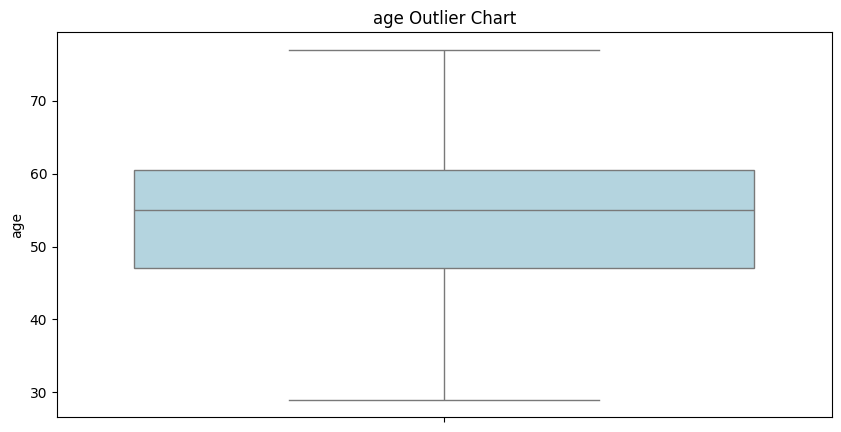

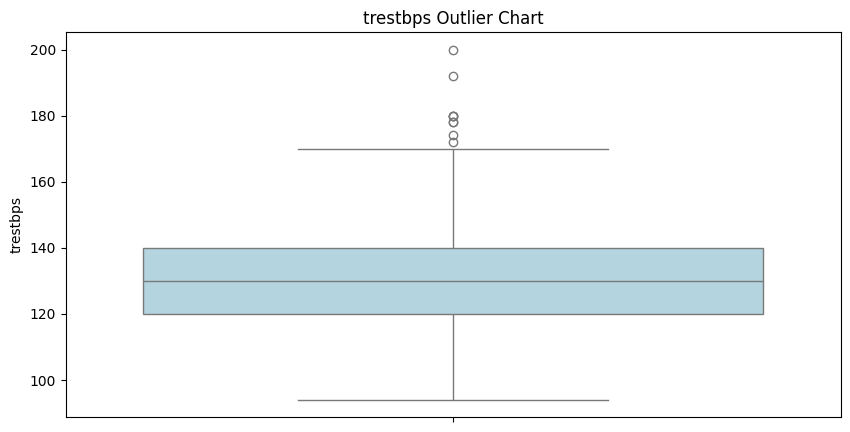

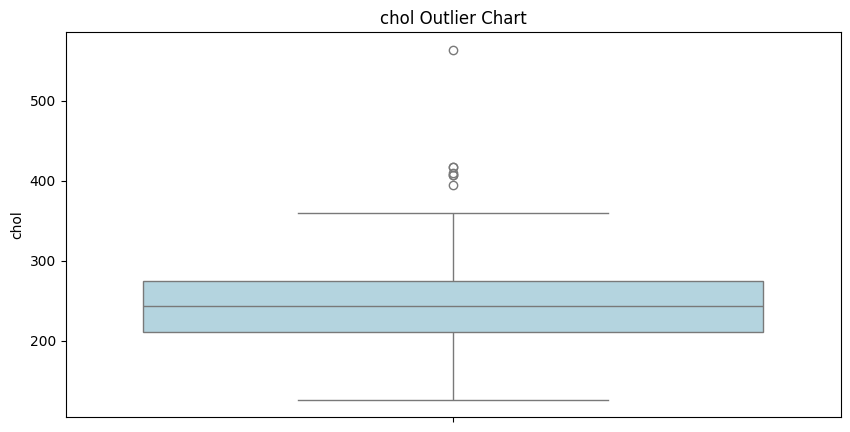

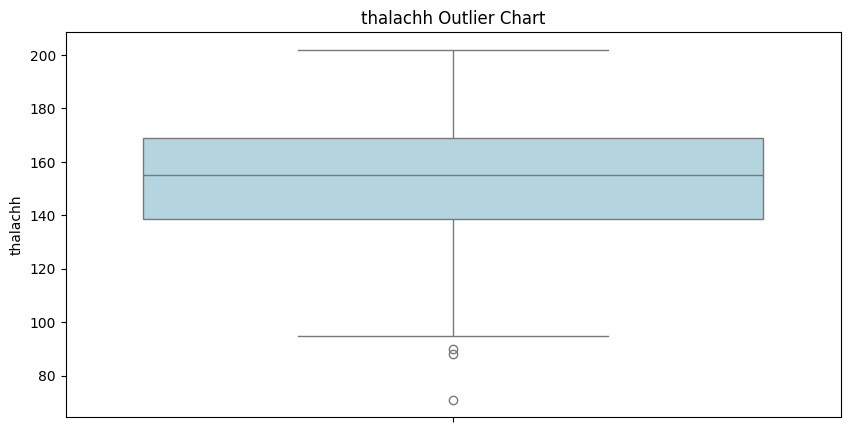

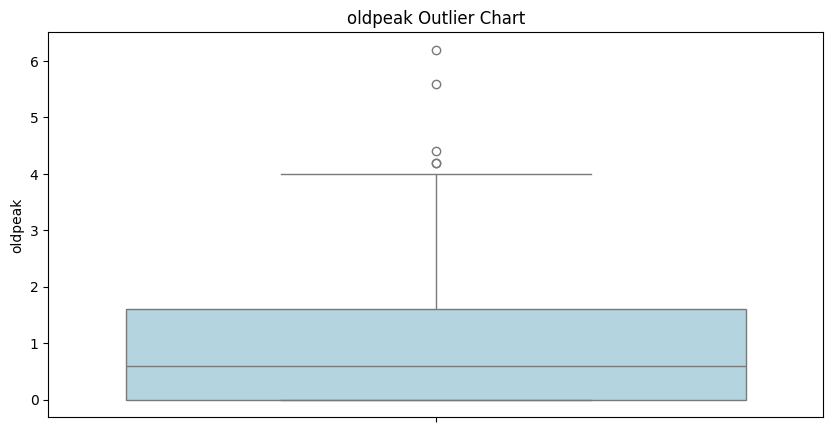

In [19]:
for col in data[numerical_features].columns:
    fig = plt.figure(figsize = (10,5))
    sns.boxplot(data = data, y = col, color = 'LightBlue')  # Boxplot for detecting outliers
    plt.title(f'{col} Outlier Chart')  # Setting the title dynamically for each column
    plt.show()  # Display the plot

C:\Users\sabri\AppData\Local\Temp\ipykernel_8040\2433981239.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['oldpeak'] = np.where(data['oldpeak'] > 5, data['oldpeak'].median(), data['oldpeak'])


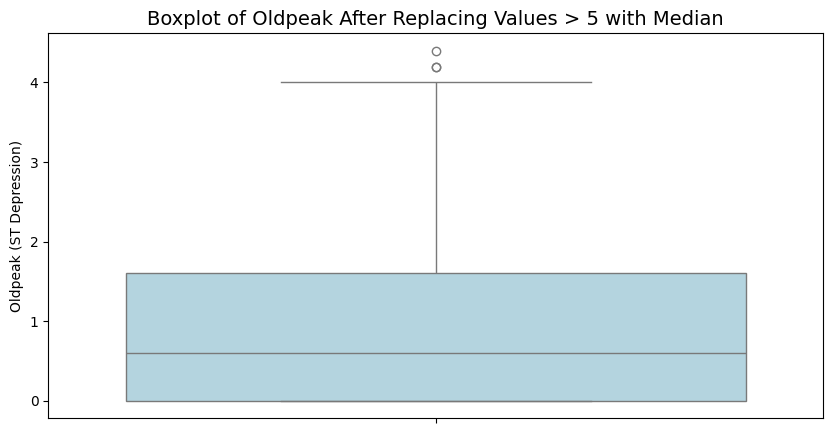

In [20]:
# Replace oldpeak > 5 with the median
data['oldpeak'] = np.where(data['oldpeak'] > 5, data['oldpeak'].median(), data['oldpeak'])

# Create a boxplot to visualize the result
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, y='oldpeak', color='lightblue')
plt.title('Boxplot of Oldpeak After Replacing Values > 5 with Median', fontsize=14)
plt.ylabel('Oldpeak (ST Depression)')
plt.show()

In [21]:
# Reset the index after dropping rows
data.reset_index(drop=True, inplace=True)
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,45,1,0,110,275,0,0,118,1,1.0,1,1,2,0
415,55,1,1,124,261,0,1,141,0,0.3,2,0,3,0
416,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
417,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0


In [22]:
# Function to categorize age
def categorize_age(age):
    if age < 19:
        return 'Young'
    elif age < 36:
        return 'Adult'
    elif age < 56:
        return 'Middle-Aged'
    else:
        return 'Senior'

# Apply the function to create a new column
data['AgeCategory'] = data['age'].apply(categorize_age)
data

C:\Users\sabri\AppData\Local\Temp\ipykernel_8040\244252572.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['AgeCategory'] = data['age'].apply(categorize_age)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target,AgeCategory
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Senior
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Middle-Aged
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,Middle-Aged
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,Senior
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,45,1,0,110,275,0,0,118,1,1.0,1,1,2,0,Middle-Aged
415,55,1,1,124,261,0,1,141,0,0.3,2,0,3,0,Middle-Aged
416,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0,Senior
417,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0,Middle-Aged


In [23]:
# Move column 'AgeCategory' to the next if 'Age'
col = data.pop('AgeCategory')
data.insert(1, 'AgeCategory', col)

In [24]:
data.head()

,age,AgeCategory,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,Senior,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,Middle-Aged,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,Middle-Aged,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,Senior,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,Senior,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Exploratory Data Analysis

In [25]:
# Display information of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          419 non-null    int64  
 1   AgeCategory  419 non-null    object 
 2   sex          419 non-null    int64  
 3   cp           419 non-null    int64  
 4   trestbps     419 non-null    int64  
 5   chol         419 non-null    int64  
 6   fbs          419 non-null    int64  
 7   restecg      419 non-null    int64  
 8   thalachh     419 non-null    int64  
 9   exang        419 non-null    int64  
 10  oldpeak      419 non-null    float64
 11  slope        419 non-null    int64  
 12  ca           419 non-null    int64  
 13  thal         419 non-null    int64  
 14  target       419 non-null    int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 49.2+ KB


In [26]:
# Display statistical value of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,419.0,54.152745,9.251952,29.0,47.0,55.0,60.5,77.0
sex,419.0,0.646778,0.478542,0.0,0.0,1.0,1.0,1.0
cp,419.0,1.295943,1.148437,0.0,0.0,1.0,2.0,3.0
trestbps,419.0,131.276850,16.925384,94.0,120.0,130.0,140.0,200.0
chol,419.0,247.284010,51.082193,126.0,211.0,243.0,275.0,564.0
fbs,419.0,0.152745,0.360171,0.0,0.0,0.0,0.0,1.0
restecg,419.0,0.601432,0.678514,0.0,0.0,0.0,1.0,2.0
thalachh,419.0,151.443914,22.509404,71.0,138.5,155.0,169.0,202.0
exang,419.0,0.281623,0.450328,0.0,0.0,0.0,1.0,1.0
oldpeak,419.0,0.963007,1.065798,0.0,0.0,0.6,1.6,4.4


In [27]:
# Display fonal converted data type
data.dtypes

age              int64
AgeCategory     object
sex              int64
cp               int64
trestbps         int64
chol             int64
fbs              int64
restecg          int64
thalachh         int64
exang            int64
oldpeak        float64
slope            int64
ca               int64
thal             int64
target           int64
dtype: object

In [28]:
# Check for missing value
data.isnull().sum()

age            0
AgeCategory    0
sex            0
cp             0
trestbps       0
chol           0
fbs            0
restecg        0
thalachh       0
exang          0
oldpeak        0
slope          0
ca             0
thal           0
target         0
dtype: int64

In [29]:
# To check the duplicated data
data.duplicated().sum()

0

In [30]:
# Drop the duplicated data
data.drop_duplicates(inplace=True)

C:\Users\sabri\AppData\Local\Temp\ipykernel_8040\898582217.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop_duplicates(inplace=True)


In [31]:
# Check the data again
data.duplicated().sum()

0

In [32]:
# To check the sum of patient, where 1 = Male, 0 = Female
data['sex'].value_counts()

sex
1    271
0    148
Name: count, dtype: int64

In [33]:
# Chest pain type (0–3): 0 = typical angina, 1 = atypical angina, etc.
data['cp'].value_counts()

cp
0    153
2    119
3     79
1     68
Name: count, dtype: int64

In [34]:
# Fasting blood sugar > 120 mg/dl (1 = True, 0 = False).
data['fbs'].value_counts()

fbs
0    355
1     64
Name: count, dtype: int64

In [35]:
# Resting electrocardiographic results (0, 1, 2).
data['restecg'].value_counts()

restecg
0    213
1    160
2     46
Name: count, dtype: int64

In [36]:
# Exercise-induced angina (1 = Yes, 0 = No).
data['exang'].value_counts()

exang
0    301
1    118
Name: count, dtype: int64

In [37]:
# Slope of the peak exercise ST segment (0–2).
data['slope'].value_counts()

slope
1    222
2    173
0     24
Name: count, dtype: int64

In [38]:
# Min and Max Cholesterol by Gender
data.groupby('sex').agg({'chol': ['min', 'max']})

chol     
     min  max
sex          
0    141  564
1    126  407

In [39]:
# Mean of Max Heart Rate by Gender
data.groupby('sex').agg({'thalachh': ['mean']})

,thalachh
,mean
sex,
0,153.621622
1,150.254613


In [40]:
# Mean of Age by Heart Disease Presence
data.groupby('target').agg({'age': ['mean']})

,age
,mean
target,
0,55.140496
1,52.802260


In [41]:
# Count of Heart Disease per Chest Pain Type
data.groupby('cp').agg({'target': ['count']})

,target
,count
cp,
0,153
1,68
2,119
3,79


In [42]:
# Count of Resting ECG per Heart Disease
data.groupby('restecg').agg({'target': ['count']})

,target
,count
restecg,
0,213
1,160
2,46


In [43]:
# Mean of Oldpeak by Gender
data.groupby('sex').agg({'oldpeak': ['mean']})

,oldpeak
,mean
sex,
0,0.725676
1,1.092620


In [44]:
# Mean of Oldpeak Heart Disease
data.groupby('target').agg({'oldpeak': ['mean']})

,oldpeak
,mean
target,
0,1.175207
1,0.672881


In [45]:
# Mean of Resting Blood Pressure by Chest Pain Type
data.groupby('cp').agg({'trestbps': ['mean']})

,trestbps
,mean
cp,
0,131.790850
1,131.250000
2,129.731092
3,132.632911


In [46]:
# Heart Disease Cases by Age
data.groupby(['age', 'target']).agg({'target': ['count']})

target
            count
age target       
29  0           1
    1           1
34  0           2
    1           2
35  0           2
...           ...
74  0           1
    1           1
76  0           1
    1           1
77  0           2

[80 rows x 1 columns]

In [47]:
# Mean of Cholesterol by Resting ECG Type
data.groupby('restecg').agg({'chol': ['mean']})

,chol
,mean
restecg,
0,251.291080
1,239.931250
2,254.304348


## Data Visualization

In [48]:
data['target'] = data['target'].astype(str)

C:\Users\sabri\AppData\Local\Temp\ipykernel_8040\2529177658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['target'] = data['target'].astype(str)


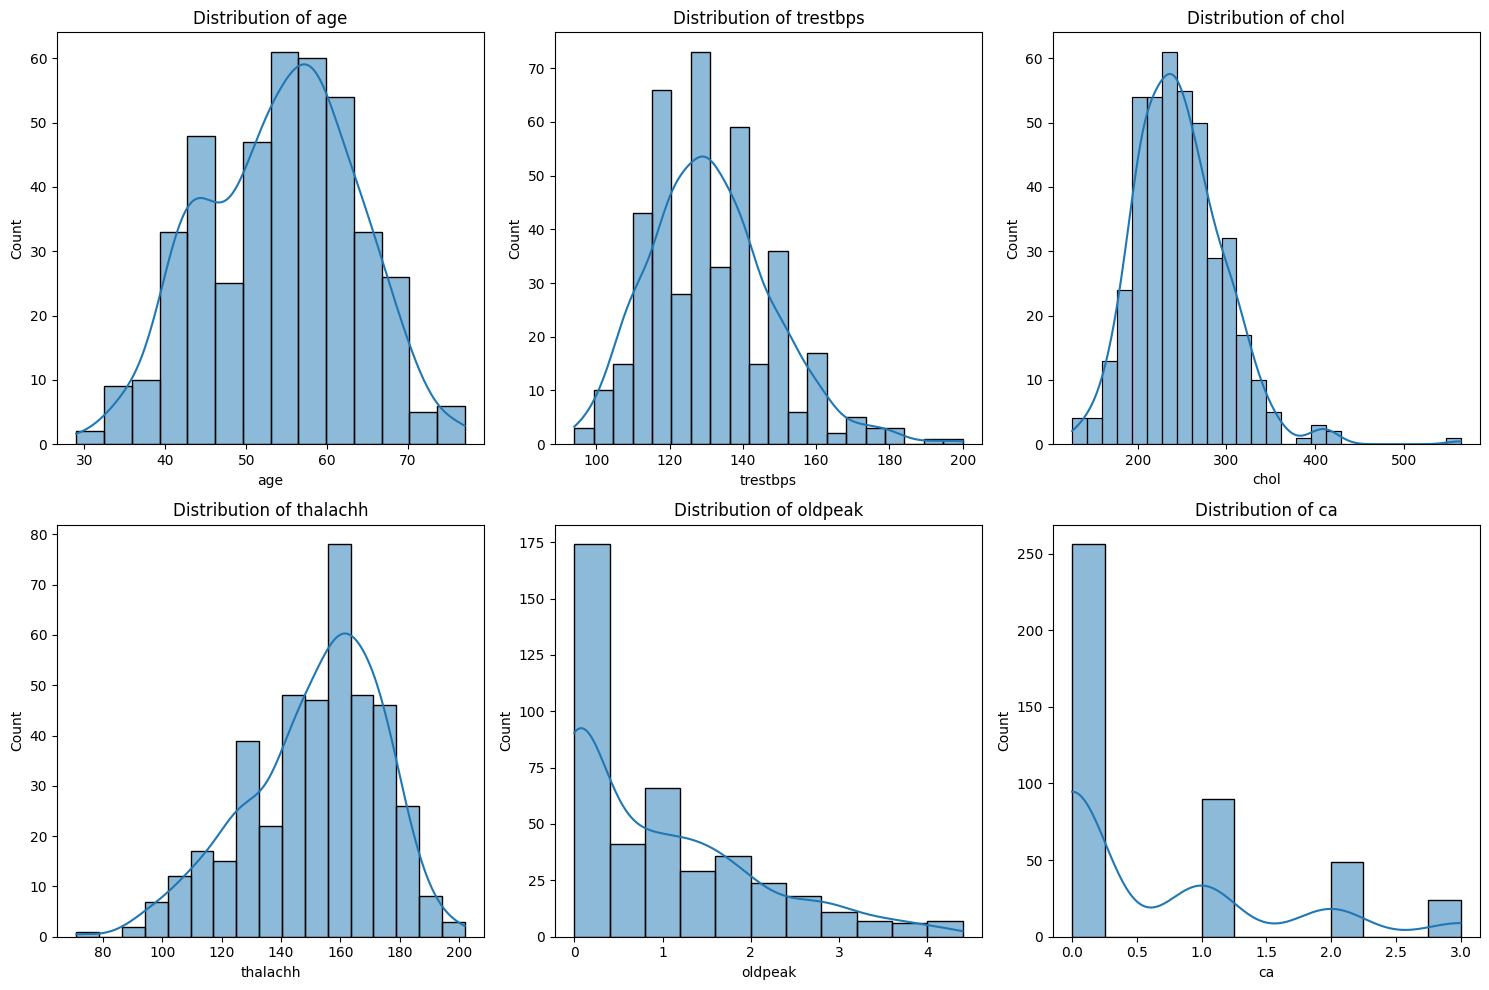

In [49]:
# Plotting numerical features
numerical_features = ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak', 'ca']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

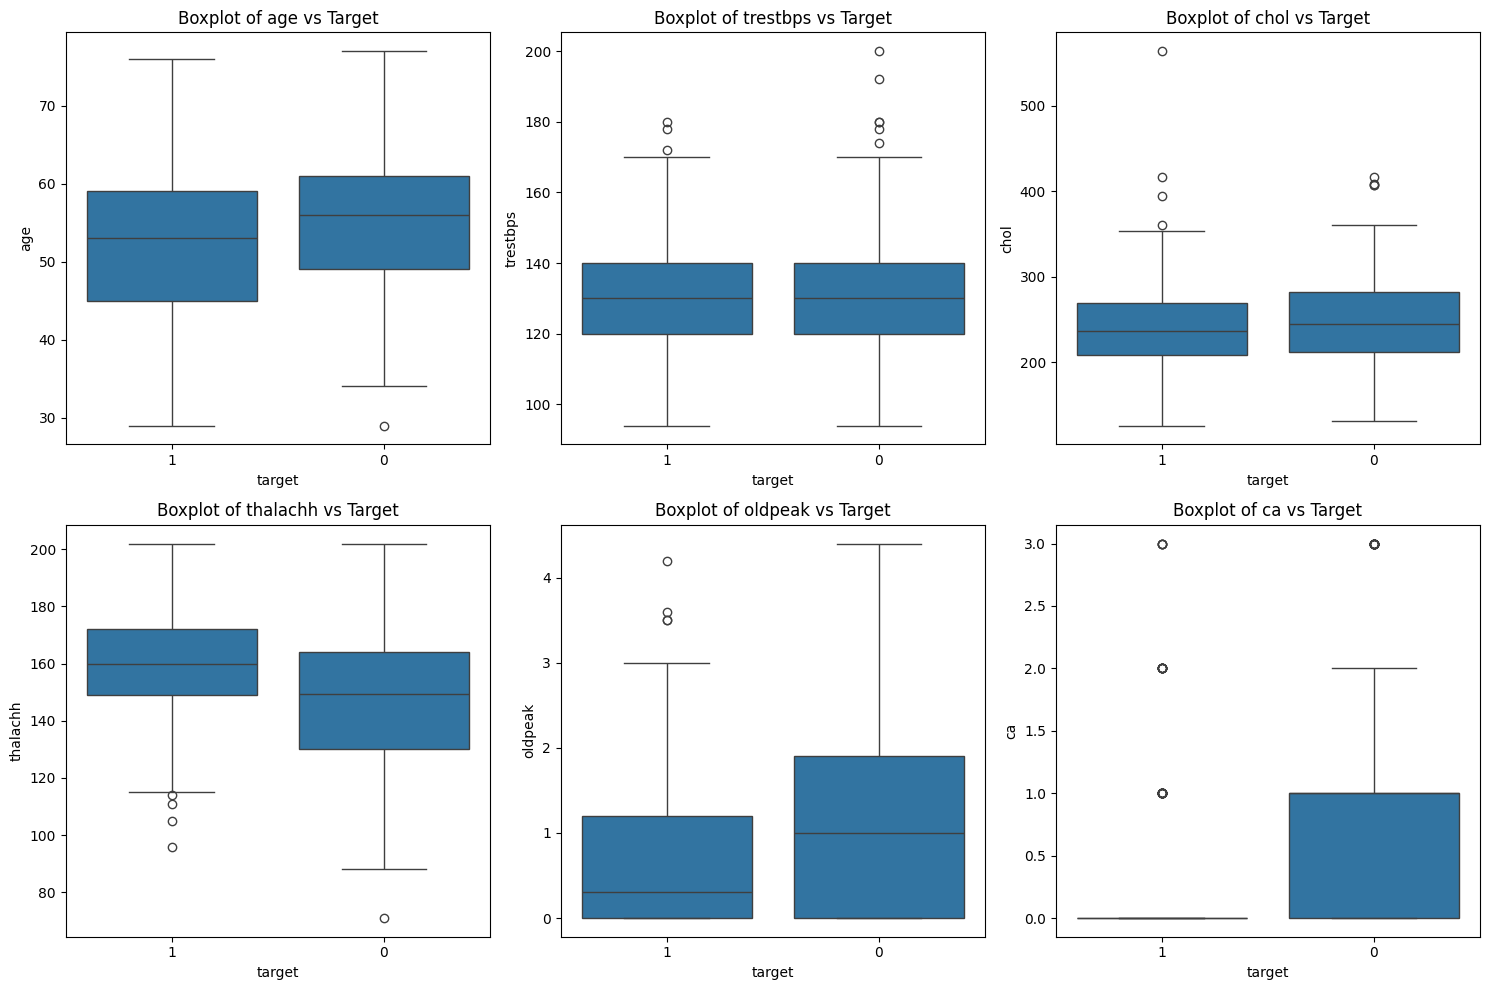

In [50]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
  plt.subplot(2, 3, i + 1)
  sns.boxplot(x='target', y=col, data=data)
  plt.title(f'Boxplot of {col} vs Target')
plt.tight_layout()
plt.show()

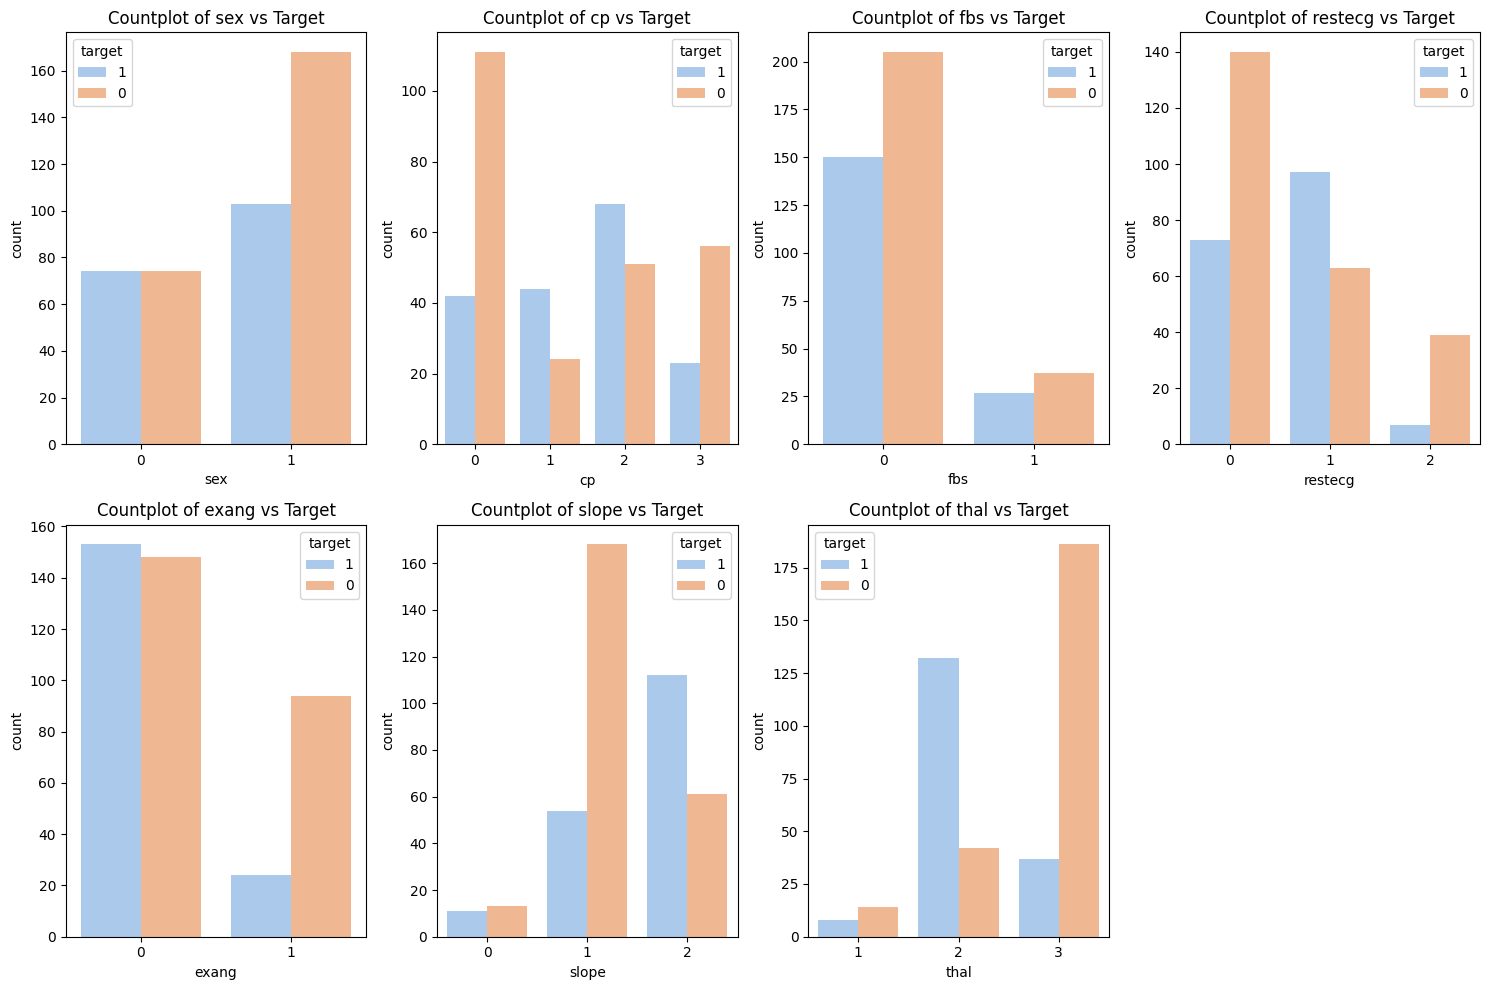

In [51]:
# Plotting categorical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 4, i + 1)
    sns.countplot(x=col, data=data, hue='target', palette='pastel')
    plt.title(f'Countplot of {col} vs Target')

plt.tight_layout()
plt.show()

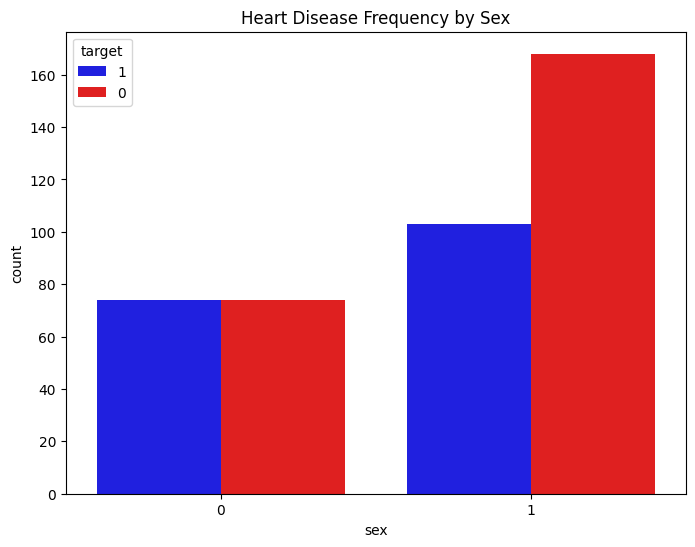

In [52]:
# Heart Disease Frequency by Sex
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='target', data=data, palette=["blue", "red"])
plt.title('Heart Disease Frequency by Sex')
plt.show()

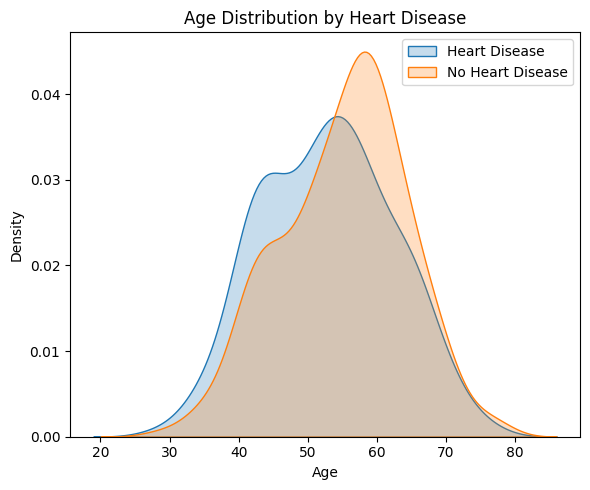

In [53]:
plt.figure(figsize=(6, 5))
sns.kdeplot(data.loc[data['target'] == '1', 'age'], label='Heart Disease', fill=True)
sns.kdeplot(data.loc[data['target'] == '0', 'age'], label='No Heart Disease', fill=True)
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution by Heart Disease')
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
data['target'] = data['target'].astype(int)

C:\Users\sabri\AppData\Local\Temp\ipykernel_8040\938211053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['target'] = data['target'].astype(int)


C:\Users\sabri\AppData\Local\Temp\ipykernel_8040\3097892217.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="sex", y="target", data=data, estimator= mean, width=0.5, palette='pastel')


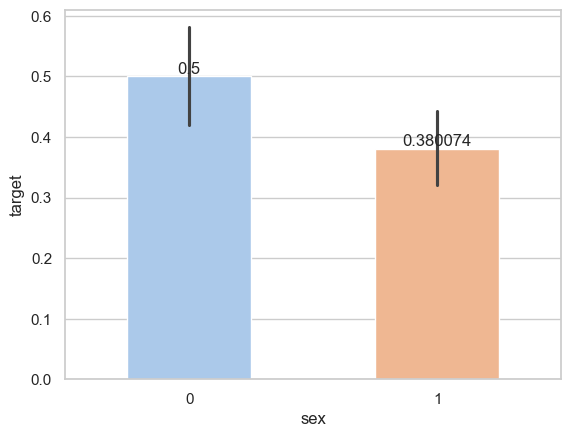

In [55]:
# the mean of each Heart Disease
sns.set(style="whitegrid")
ax = sns.barplot(x="sex", y="target", data=data, estimator= mean, width=0.5, palette='pastel')

for label in ax.containers:
    ax.bar_label(label)

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['AgeCategory'] = le.fit_transform(data['AgeCategory'])

C:\Users\sabri\AppData\Local\Temp\ipykernel_8040\2522451229.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['AgeCategory'] = le.fit_transform(data['AgeCategory'])


In [57]:
data.corr()

,age,AgeCategory,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
age,1.000000,0.850486,-0.103959,-0.102658,0.320511,0.213225,0.167438,-0.046681,-0.410052,0.120568,0.193913,-0.086238,0.358404,-0.008111,-0.124984
AgeCategory,0.850486,1.000000,-0.060129,-0.116407,0.299561,0.179266,0.148822,-0.084048,-0.338749,0.116807,0.215984,-0.110427,0.310993,-0.030638,-0.136037
sex,-0.103959,-0.060129,1.000000,-0.135818,-0.020388,-0.180169,0.036175,-0.058855,-0.071581,0.140767,0.164758,-0.045736,0.082167,0.067062,-0.116047
cp,-0.102658,-0.116407,-0.135818,1.000000,-0.005948,-0.074392,0.121803,0.108752,0.300397,-0.411333,-0.182578,0.010308,-0.260621,0.134575,0.082637
trestbps,0.320511,0.299561,-0.020388,-0.005948,1.000000,0.135577,0.178672,-0.032657,-0.056192,0.039652,0.178082,-0.105293,0.110229,0.004588,-0.076885
chol,0.213225,0.179266,-0.180169,-0.074392,0.135577,1.000000,0.046138,-0.036622,0.014136,0.058602,0.073352,-0.026834,0.133385,0.069277,-0.045482
fbs,0.167438,0.148822,0.036175,0.121803,0.178672,0.046138,1.000000,0.014766,-0.018121,-0.015102,-0.003942,-0.065169,0.127188,-0.007817,-0.000481
restecg,-0.046681,-0.084048,-0.058855,0.108752,-0.032657,-0.036622,0.014766,1.000000,0.045133,-0.078052,-0.055173,0.062391,-0.099095,0.107114,0.032415
thalachh,-0.410052,-0.338749,-0.071581,0.300397,-0.056192,0.014136,-0.018121,0.045133,1.000000,-0.392103,-0.339531,0.287512,-0.254227,-0.007171,0.262284
exang,0.120568,0.116807,0.140767,-0.411333,0.039652,0.058602,-0.015102,-0.078052,-0.392103,1.000000,0.288428,-0.180667,0.151695,0.074794,-0.277658


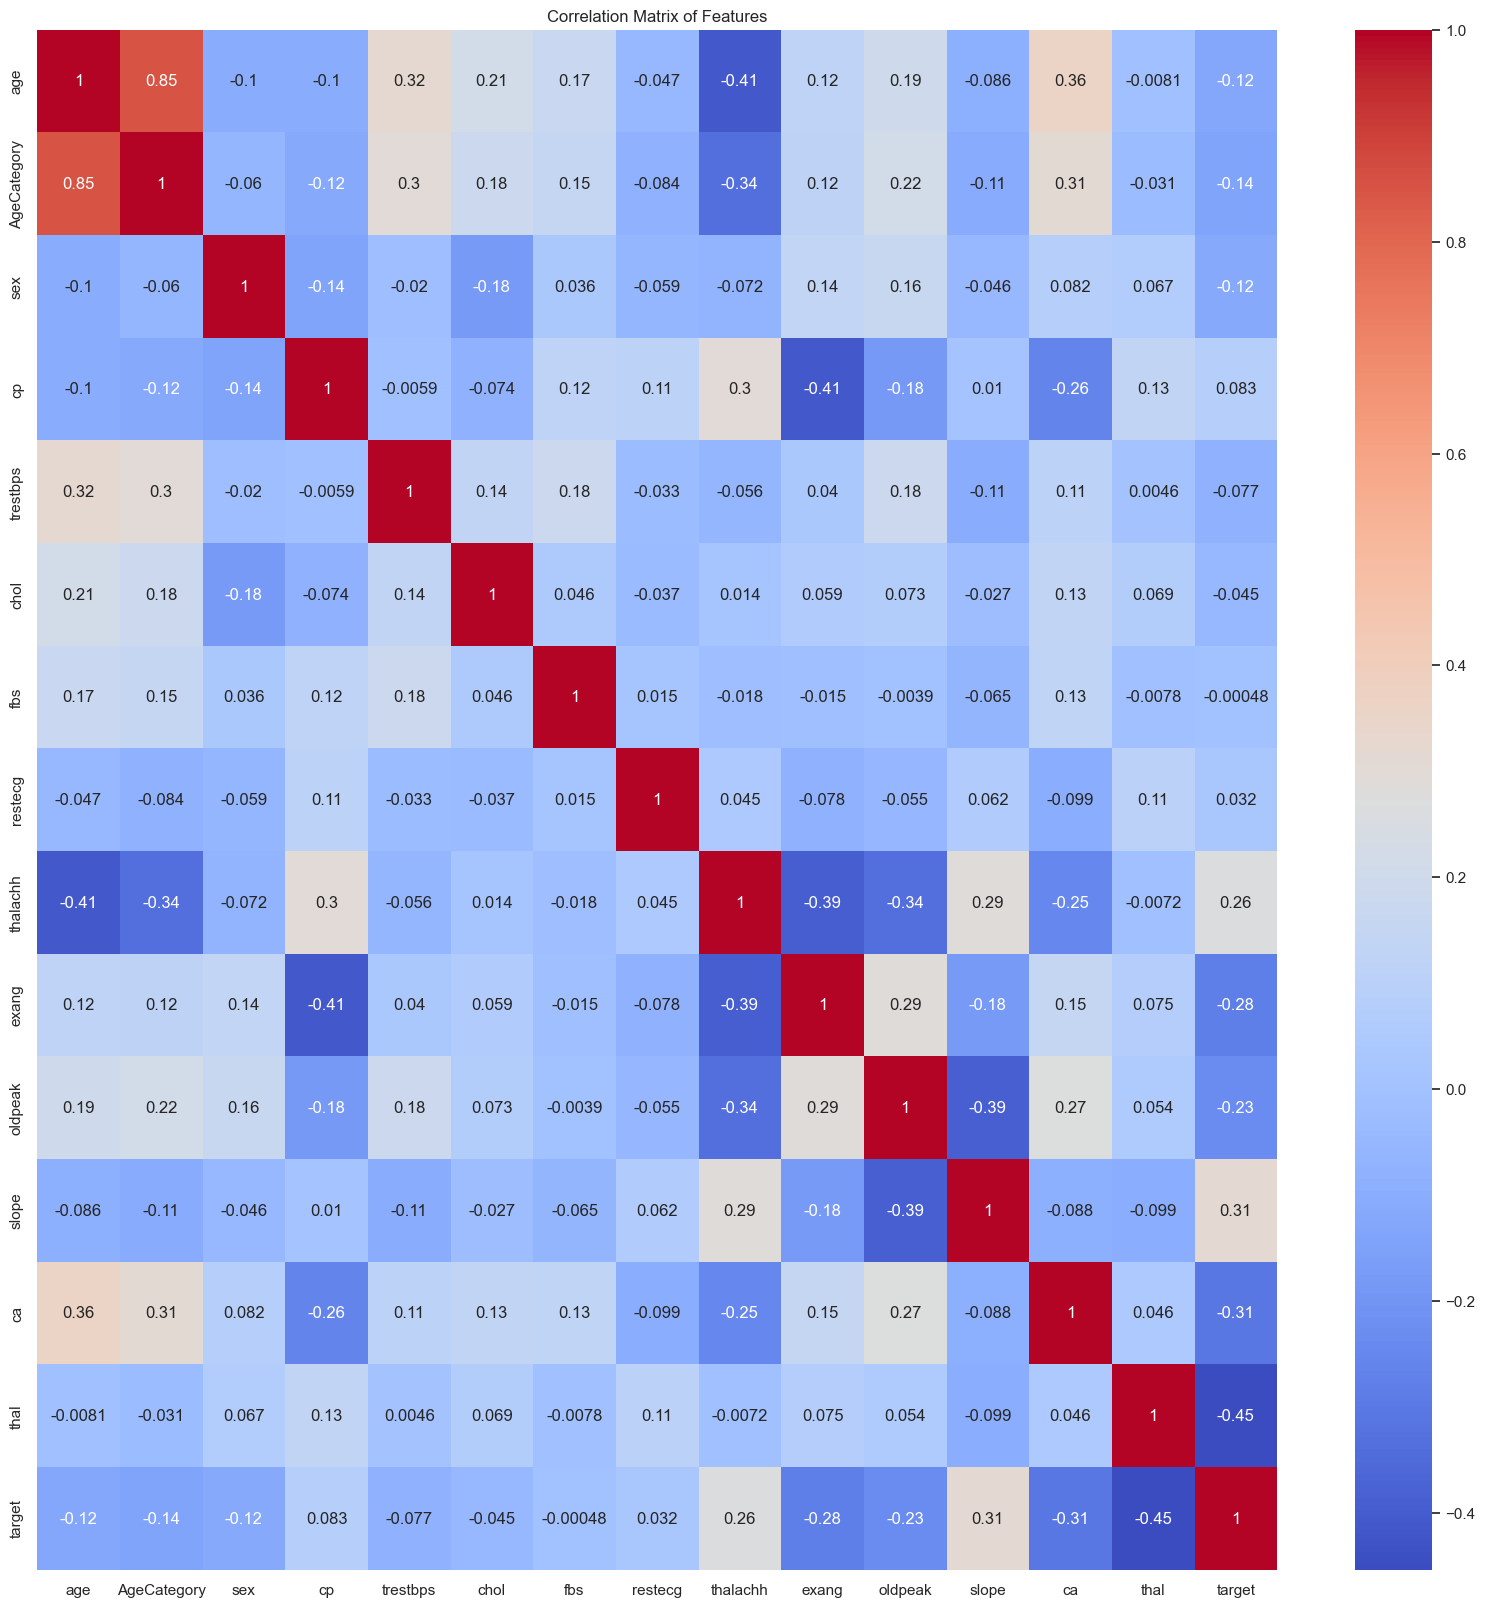

In [58]:
# Correlation Heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', annot_kws={"size": 12})
plt.title('Correlation Matrix of Features')
plt.show()

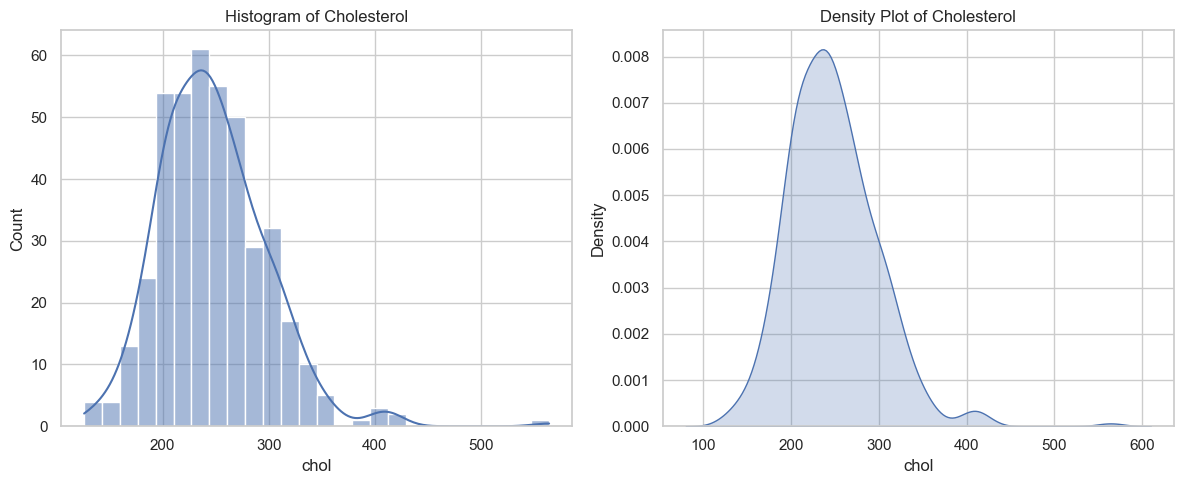

In [59]:
# plot the graph of cholesterol
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data['chol'], kde=True, ax=ax[0])
ax[0].set_title('Histogram of Cholesterol')
sns.kdeplot(data['chol'], ax=ax[1],fill=True)
ax[1].set_title('Density Plot of Cholesterol')
plt.tight_layout()
plt.show()

In [60]:
data['target'] = data['target'].astype(str)

C:\Users\sabri\AppData\Local\Temp\ipykernel_8040\2529177658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['target'] = data['target'].astype(str)


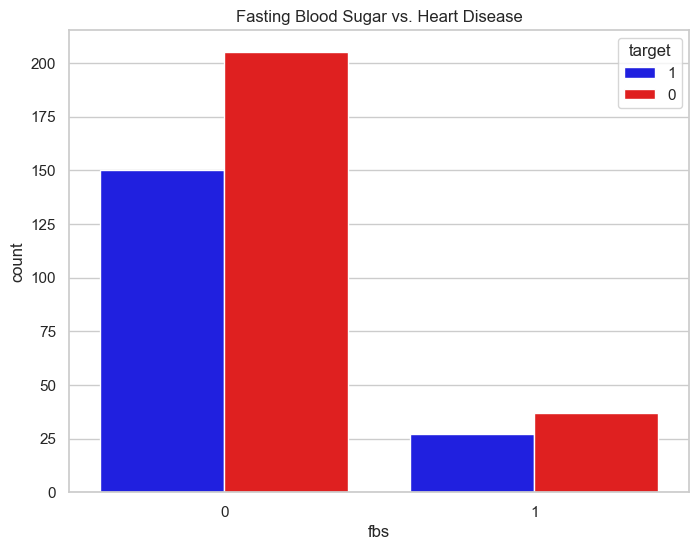

In [61]:
# Graph of Fastings and HeartDisease
plt.figure(figsize=(8, 6))
sns.countplot(x='fbs', hue='target', data=data, palette=['blue', 'red'])
plt.title('Fasting Blood Sugar vs. Heart Disease')
plt.show()

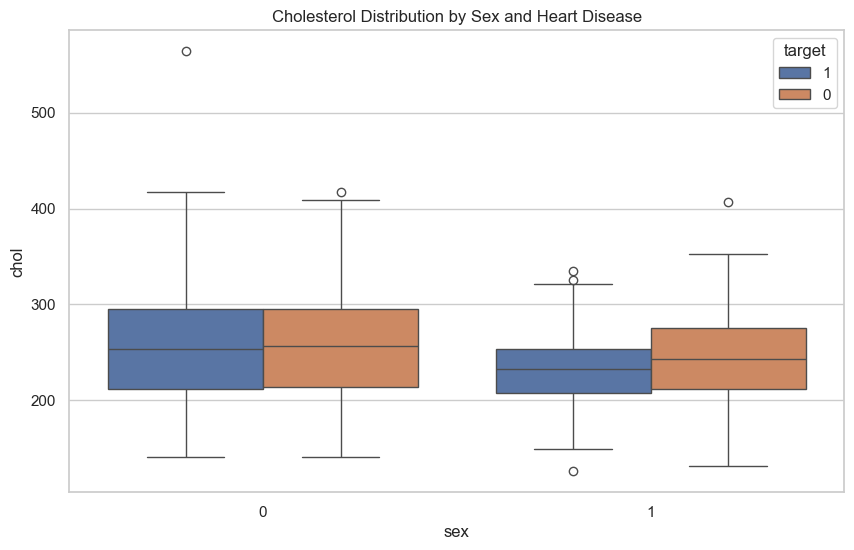

In [62]:
# Boxplot of Cholesterol by Gender and Heart Disease
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='chol', hue='target', data=data)
plt.title('Cholesterol Distribution by Sex and Heart Disease')
plt.show()

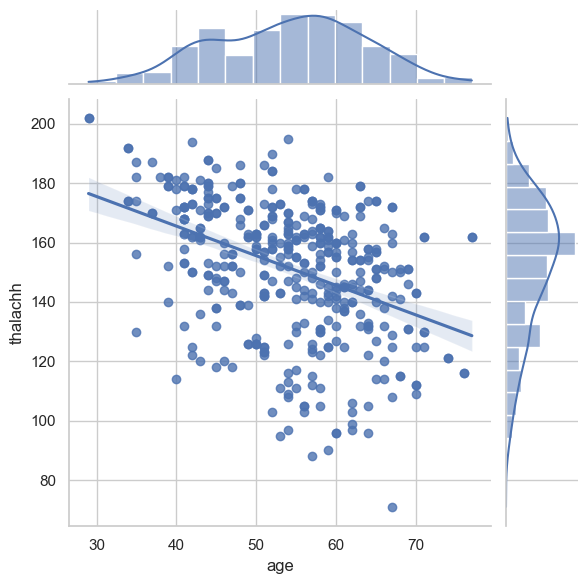

In [63]:
sns.jointplot(x = 'age', y = 'thalachh', data = data, kind = 'reg')
# As the Age increases the heart rate is decreases

## Discussion

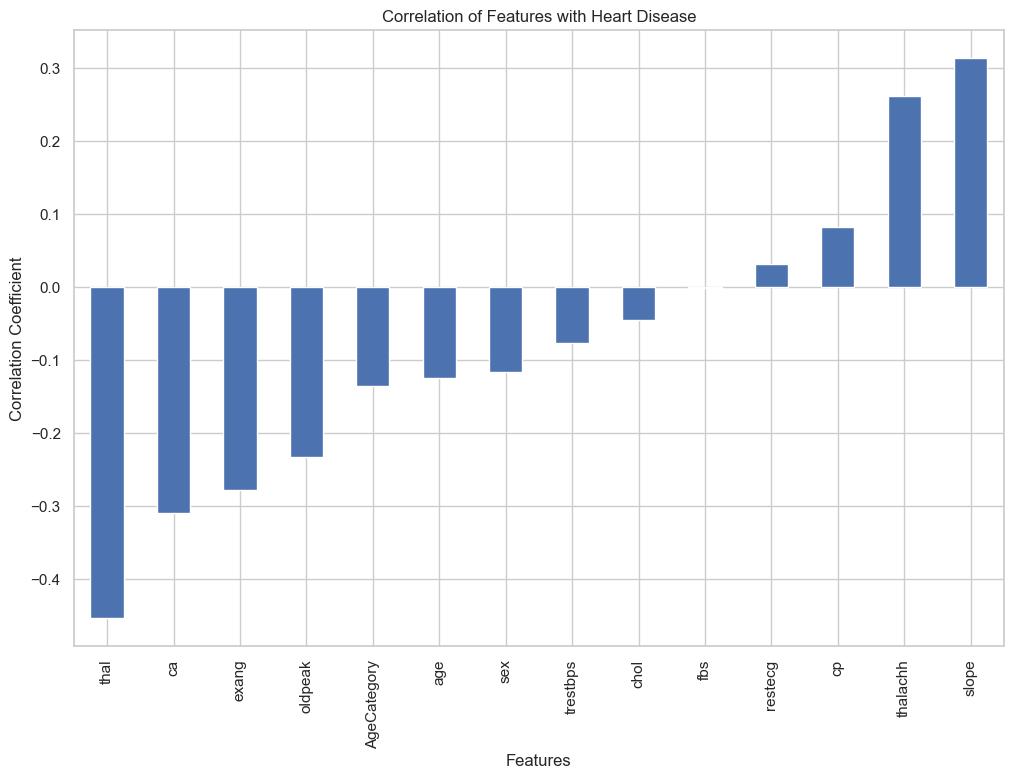

In [64]:
# Question 1: Discussion
plt.figure(figsize=(12, 8))
data.corr()['target'].drop('target').sort_values().plot(kind='bar')
plt.title('Correlation of Features with Heart Disease')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.show()

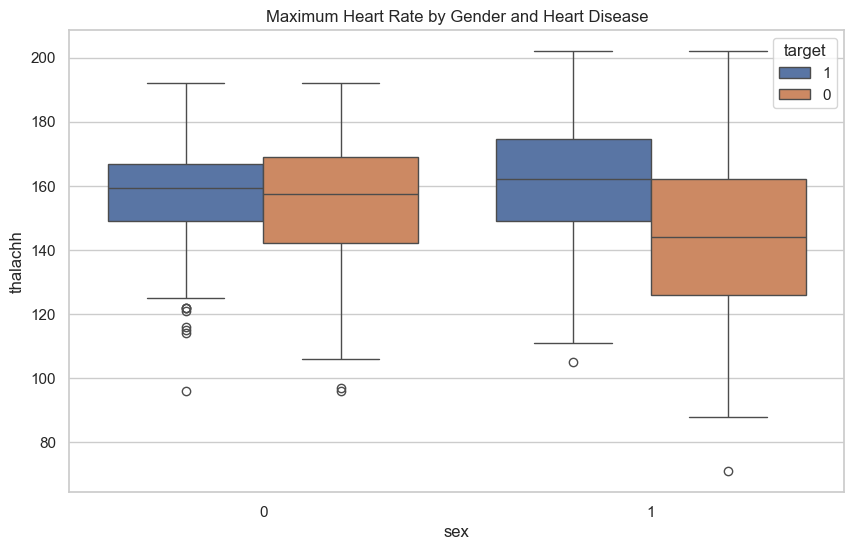

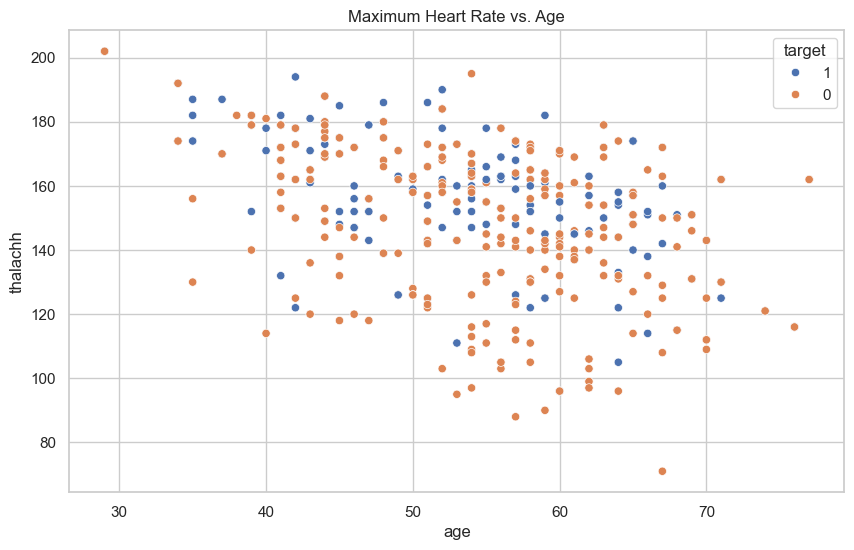

In [65]:
# Question 2: Discussion
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='thalachh', hue='target', data=data)
plt.title('Maximum Heart Rate by Gender and Heart Disease')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='thalachh', hue='target', data=data)
plt.title('Maximum Heart Rate vs. Age')
plt.show()

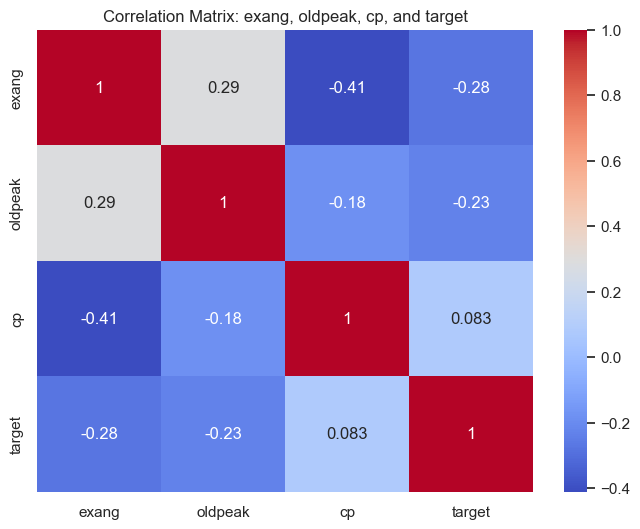

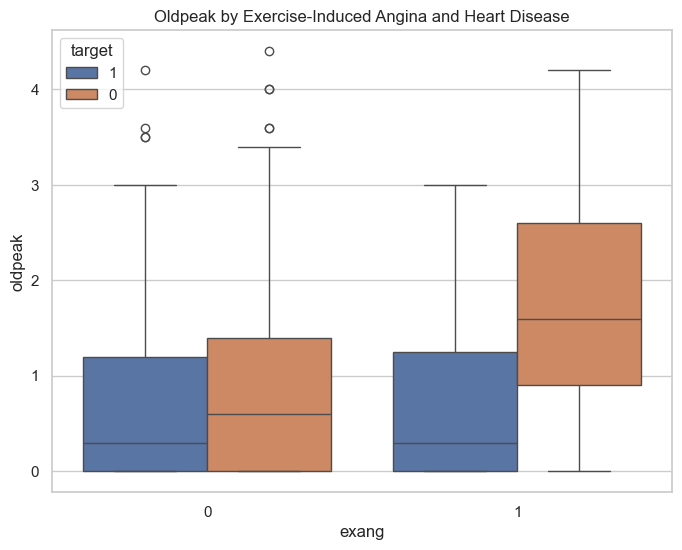

In [66]:
# Question 3: Discussion
plt.figure(figsize=(8, 6))
sns.heatmap(data[['exang', 'oldpeak', 'cp', 'target']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: exang, oldpeak, cp, and target')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='exang', y='oldpeak', hue='target', data=data)
plt.title('Oldpeak by Exercise-Induced Angina and Heart Disease')
plt.show()

In [67]:
# Question 4: Discussion
# Prepare the data
X = data.drop('target', axis=1)
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [69]:
# Make predictions
y_pred = model.predict(X_test)

In [70]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7976190476190477
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        46
           1       0.78      0.76      0.77        38

    accuracy                           0.80        84
   macro avg       0.80      0.79      0.80        84
weighted avg       0.80      0.80      0.80        84

[[38  8]
 [ 9 29]]


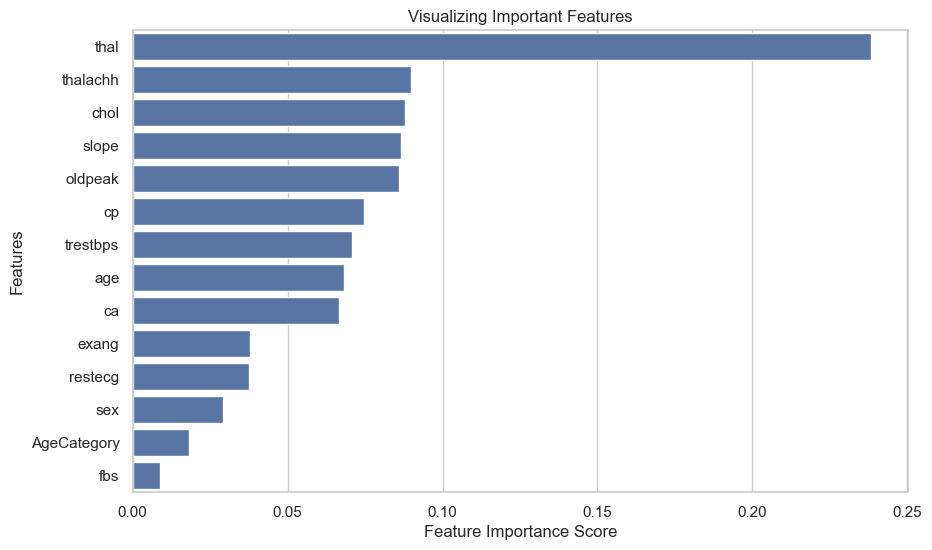

In [71]:
feature_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Visualizing Important Features')
plt.show()